<a href="https://colab.research.google.com/github/Simpson69-il/DEEPLEARNING5THSEM/blob/main/EXPERIMENT%205/EX5(24BAD074).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNN Text Generation Using Tiny Shakespeare

**Student Roll No:** 24BAD074  
**Name:** Mohd Shafique R B

## AIM
To implement a Recurrent Neural Network (RNN) for text generation and evaluate its ability to generate meaningful text by predicting the next word in a sequence.

## SOFTWARE REQUIREMENTS
- Python
- TensorFlow / Keras
- Google Colab
- GitHub
- NumPy
- Matplotlib
- Hugging Face Datasets

# TASK A: DATASET PREPARATION

### Important
The original `tiny_shakespeare.py` dataset loader is no longer supported by recent Hugging Face `datasets` versions. Therefore, this notebook loads the **Parquet version of Tiny Shakespeare directly from the Hugging Face dataset repository**, avoiding the deprecated dataset script.

In [1]:
# Student Roll No: 24BAD074
!pip install -q datasets pyarrow

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Student Roll No: 24BAD074
# Load Tiny Shakespeare from Hugging Face Parquet files.
# This avoids the deprecated tiny_shakespeare.py dataset script.

HF_BASE = 'https://huggingface.co/datasets/karpathy/tiny_shakespeare/resolve/refs%2Fpr%2F2/data/'

train_url = HF_BASE + 'train-00000-of-00001.parquet'
validation_url = HF_BASE + 'validation-00000-of-00001.parquet'

dataset = load_dataset(
    'parquet',
    data_files={
        'train': train_url,
        'validation': validation_url
    }
)

print(dataset)

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  634kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 35.8kB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 1
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 1
    })
})


In [3]:
# Student Roll No: 24BAD074
print('Training samples:', len(dataset['train']))
print('Validation samples:', len(dataset['validation']))
print('\nFirst training sample:\n')
print(dataset['train'][0]['text'][:1000])

Training samples: 1
Validation samples: 1

First training sample:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods 

In [4]:
# Student Roll No: 24BAD074
text = dataset['train'][0]['text'].lower()
print('Total characters:', len(text))
print('\nSample text:\n')
print(text[:1000])

Total characters: 1003854

Sample text:

first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor citizens, the patricians good.
what authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them let us revenge this with
our pikes, ere we become rakes: for the gods know i
speak this in hunge

In [5]:
# Student Roll No: 24BAD074
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts([text])
total_words = min(10000, len(tokenizer.word_index) + 1)
print('Vocabulary size:', total_words)

Vocabulary size: 10000


In [6]:
# Student Roll No: 24BAD074
sequences = []

for line in text.split('\n'):
    if not line.strip():
        continue
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(2, len(token_list) + 1):
        sequences.append(token_list[:i])

print('Total sequences:', len(sequences))

Total sequences: 154531


In [7]:
# Student Roll No: 24BAD074
max_sequence_len = max(len(seq) for seq in sequences)
print('Maximum sequence length:', max_sequence_len)

sequences = np.array(
    pad_sequences(sequences, maxlen=max_sequence_len, padding='pre')
)

X = sequences[:, :-1]
y = sequences[:, -1]

print('Input shape:', X.shape)
print('Output shape:', y.shape)

Maximum sequence length: 16
Input shape: (154531, 15)
Output shape: (154531,)


In [8]:
# Student Roll No: 24BAD074
split = int(0.9 * len(X))

X_train, y_train = X[:split], y[:split]
X_val, y_val = X[split:], y[split:]

print('Training samples:', len(X_train))
print('Validation samples:', len(X_val))

Training samples: 139077
Validation samples: 15454


# TASK B: IMPLEMENTING THE RNN MODEL

In [9]:
# Student Roll No: 24BAD074
embedding_dim = 64
rnn_units = 128

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=total_words, output_dim=embedding_dim),
    tf.keras.layers.SimpleRNN(rnn_units),
    tf.keras.layers.Dense(total_words, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model Architecture

`Input → Embedding → Simple RNN → Dense + Softmax → Next Word Prediction`

# TASK C: RNN MODEL TRAINING AND PERFORMANCE EVALUATION

In [10]:
# Student Roll No: 24BAD074
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128
)

Epoch 1/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 103s 90ms/step - accuracy: 0.0492 - loss: 6.7023 - val_accuracy: 0.0740 - val_loss: 6.1744
Epoch 2/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 96s 89ms/step - accuracy: 0.0863 - loss: 6.0548 - val_accuracy: 0.0888 - val_loss: 5.9835
Epoch 3/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 140s 87ms/step - accuracy: 0.1009 - loss: 5.7353 - val_accuracy: 0.0945 - val_loss: 5.9598
Epoch 4/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 95s 88ms/step - accuracy: 0.1111 - loss: 5.4845 - val_accuracy: 0.1058 - val_loss: 5.9384
Epoch 5/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 95s 87ms/step - accuracy: 0.1193 - loss: 5.2676 - val_accuracy: 0.0911 - val_loss: 5.9924
Epoch 6/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 147s 92ms/step - accuracy: 0.1292 - loss: 5.0747 - val_accuracy: 0.1063 - val_loss: 6.0148
Epoch 7/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 97s 89ms/step - accuracy: 0.1405 - loss: 4.8944 - val_accuracy: 0.0936 - val_loss: 6.0774
Epoch 8/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 97s 89ms/step - accuracy: 0.154

In [11]:
# Student Roll No: 24BAD074
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print('Validation Loss:', loss)
print('Validation Accuracy:', accuracy)

print('\nTraining Accuracy:')
print(history.history['accuracy'])
print('\nValidation Accuracy:')
print(history.history['val_accuracy'])
print('\nTraining Loss:')
print(history.history['loss'])
print('\nValidation Loss:')
print(history.history['val_loss'])

Validation Loss: 6.257017135620117
Validation Accuracy: 0.08929727226495743

Training Accuracy:
[0.0492389090359211, 0.08626876026391983, 0.10092969983816147, 0.11107516288757324, 0.11927206069231033, 0.1292305737733841, 0.14045457541942596, 0.15432457625865936, 0.16769127547740936, 0.18498386442661285]

Validation Accuracy:
[0.07402614504098892, 0.08877960592508316, 0.0945386290550232, 0.10579784959554672, 0.09110909700393677, 0.1062508076429367, 0.09363271296024323, 0.09227384626865387, 0.09052672237157822, 0.08929727226495743]

Training Loss:
[6.702315807342529, 6.054793834686279, 5.735288143157959, 5.484522342681885, 5.267622470855713, 5.074737071990967, 4.894359111785889, 4.726476669311523, 4.569136142730713, 4.418406009674072]

Validation Loss:
[6.174380779266357, 5.983465671539307, 5.959827899932861, 5.938398361206055, 5.9923624992370605, 6.014827251434326, 6.0773844718933105, 6.130909442901611, 6.191287994384766, 6.257017135620117]


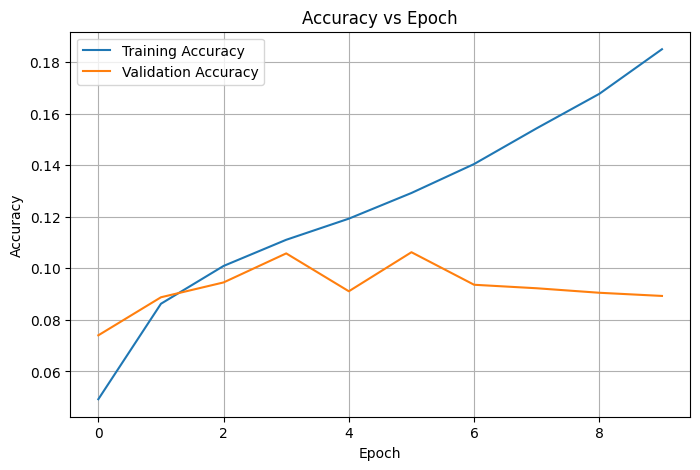

In [12]:
# Student Roll No: 24BAD074
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

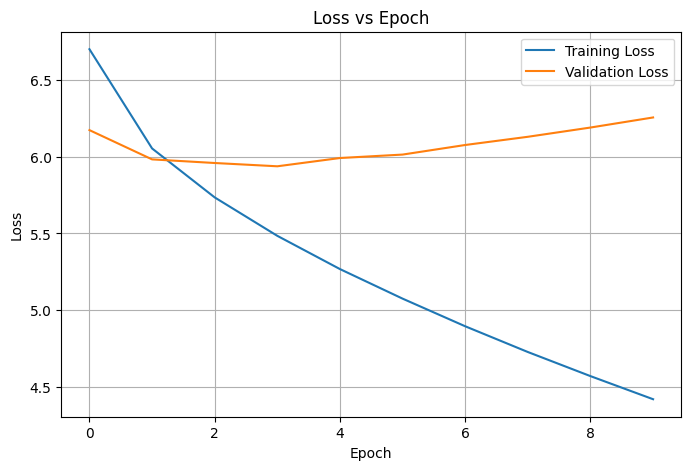

In [13]:
# Student Roll No: 24BAD074
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

# TASK D: DEEP LEARNING EXPERIMENT MANAGEMENT

In [14]:
# Student Roll No: 24BAD074
def generate_text(seed_text, next_words=20):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len - 1,
            padding='pre'
        )
        predicted_probs = model.predict(token_list, verbose=0)
        predicted_id = np.argmax(predicted_probs, axis=-1)[0]
        output_word = ''
        for word, index in tokenizer.word_index.items():
            if index == predicted_id:
                output_word = word
                break
        seed_text += ' ' + output_word
    return seed_text

In [15]:
# Student Roll No: 24BAD074
seeds = ['to be', 'the king', 'my lord', 'what is', 'i will']

for seed in seeds:
    print('\nSeed:', seed)
    print('Generated:', generate_text(seed, next_words=20))


Seed: to be
Generated: to be a <OOV> of a feast of it is the very king of death is slain and dry us fly and

Seed: the king
Generated: the king of norfolk i will not be a man to thee and i am sure of me that i am sure

Seed: my lord
Generated: my lord of hereford and the moveables cheering up the earth and death ' edward and be gone ' and i am

Seed: what is
Generated: what is the matter of the people and his own notion souls thy wife is well and so much you to be

Seed: i will
Generated: i will not stay to me and i am so to the king and so much of you love the king and


## OBSERVATION

The Simple RNN learned sequential patterns from the Tiny Shakespeare dataset and generated text based on different seed words. The generated text showed some contextual relationship with the input, although it was not always grammatically correct or completely coherent. Increasing training epochs and using advanced architectures such as LSTM or GRU can improve the quality of generated text.

## RESULT

The Recurrent Neural Network was successfully implemented using TensorFlow/Keras for next-word prediction and text generation using the Tiny Shakespeare dataset. The model was trained and evaluated using training and validation accuracy and loss, and it successfully generated multiple text samples from different seed inputs.